
# Project: Fraud Detection —  Transaction Evaluation
# File required: transactional-sample.csv


In [41]:
from google.colab import files
uploaded = files.upload()


Saving transactional-sample.csv to transactional-sample.csv


In [42]:
import io, pandas as pd
def read_csv_best_effort(fname):
    try:
        return pd.read_csv(io.BytesIO(uploaded[fname]), sep=None, engine="python")
    except Exception:
        pass
    try:
        return pd.read_csv(io.BytesIO(uploaded[fname]))
    except Exception:
        pass

    return pd.read_csv(io.BytesIO(uploaded[fname]), sep=r"\s+", engine="python")

df = read_csv_best_effort("transactional-sample.csv")
df.head()

,transaction_id,merchant_id,user_id,card_number,transaction_date,transaction_amount,device_id,has_cbk
0,21320398,29744,97051,434505******9116,2019-12-01T23:16:32.812632,374.56,285475.0,False
1,21320399,92895,2708,444456******4210,2019-12-01T22:45:37.873639,734.87,497105.0,True
2,21320400,47759,14777,425850******7024,2019-12-01T22:22:43.021495,760.36,NaN,False
3,21320401,68657,69758,464296******3991,2019-12-01T21:59:19.797129,2556.13,NaN,True
4,21320402,54075,64367,650487******6116,2019-12-01T21:30:53.347051,55.36,860232.0,False


In [43]:

import numpy as np

df.columns = [c.strip() for c in df.columns]

if 'transaction_date' in df.columns:
    df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

if 'has_cbk' in df.columns:
    df['has_cbk'] = df['has_cbk'].astype(str).str.upper().isin(['TRUE','T','1'])

if 'transaction_amount' in df.columns:
    df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')

if 'device_id' in df.columns:
    # leave NaNs as-is, convert others to Int64 to avoid 497105.0 style
    try:
        df['device_id'] = df['device_id'].astype('Int64')
    except Exception:
        pass

print(df.head())
print(df.info())

num_summary = df.select_dtypes(include=[np.number]).describe()
print(num_summary)

if 'has_cbk' in df.columns:
    print("Overall chargeback rate:", float(df['has_cbk'].mean()))


   transaction_id  merchant_id  user_id       card_number  \
0        21320398        29744    97051  434505******9116   
1        21320399        92895     2708  444456******4210   
2        21320400        47759    14777  425850******7024   
3        21320401        68657    69758  464296******3991   
4        21320402        54075    64367  650487******6116   

            transaction_date  transaction_amount  device_id  has_cbk  
0 2019-12-01 23:16:32.812632              374.56     285475    False  
1 2019-12-01 22:45:37.873639              734.87     497105     True  
2 2019-12-01 22:22:43.021495              760.36       <NA>    False  
3 2019-12-01 21:59:19.797129             2556.13       <NA>     True  
4 2019-12-01 21:30:53.347051               55.36     860232    False  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3199 entries, 0 to 3198
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  ----

#**Transaction Overview:**

The dataset has 3,199 transactions in total.

Count = 3199 → all transactions have an amount.

Mean ≈ 767.8 → the average transaction is around 768.

Median (50%) ≈ 415.9 → half of all transactions are below 416.

Std dev ≈ 889.1 → large variation, some transactions are much higher than average.

Min = 1.22 → probably test or micro-purchase.

Max = 4097.21 → high-value purchase, possibly high-risk.


*   The gap between the mean (768) and median (416) shows a right-skewed distribution. A few big-value transactions pull up the average. This is typical of card payments, but also relevant because fraudsters often prefer higher amounts once they confirm a stolen card works.
*   Roughly 2,369 unique devices across 3,199 transactions.

*   12.22% of all transactions were charged back.That’s very high in real payment environments, normal is <1%; even 2–3% triggers network penalties (e.g., Visa/Mastercard fines).So, dataset is a high-risk portfolio


## **Fraud Behavior Analysis**



In [44]:
#  Grouped views (users, devices, merchants)

import numpy as np
import pandas as pd

df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['has_cbk'] = df['has_cbk'].astype(bool)

if 'device_id' in df.columns:
    try:
        df['device_id'] = df['device_id'].astype('Int64')
    except Exception:
        pass

# Rolling Counts (User and Device)

if 'user_tx_10m' not in df.columns:
    helper = df[['user_id', 'transaction_id', 'transaction_date']].copy().set_index('transaction_date')
    rolled = (helper.groupby('user_id')['transaction_id']
              .rolling('10min').count()
              .rename('user_tx_10m')
              .reset_index())
    df = df.merge(rolled, on=['user_id', 'transaction_date'], how='left')

if ('device_id' in df.columns) and ('device_tx_10m' not in df.columns):
    df_dev = df.dropna(subset=['device_id']).copy()
    helper_d = df_dev[['device_id', 'transaction_id', 'transaction_date']].set_index('transaction_date')
    rolled_d = (helper_d.groupby('device_id')['transaction_id']
                .rolling('10min').count()
                .rename('device_tx_10m')
                .reset_index())
    df = df.merge(rolled_d, on=['device_id', 'transaction_date'], how='left')

# Helper Functions

mad = lambda s: float((s - s.median()).abs().median()) if s.notna().sum() else np.nan
iqr = lambda s: float(s.quantile(0.75) - s.quantile(0.25)) if s.notna().sum() else np.nan
p95 = lambda s: float(s.quantile(0.95)) if s.notna().sum() else np.nan
share = lambda s: float(np.mean(s)) if len(s) else np.nan

# High Ticket Calculation

P95 = df['transaction_amount'].quantile(0.95) if df['transaction_amount'].notna().any() else 2000.0
HIGH_TICKET = max(2000.0, float(P95))

# BY USER

by_user = (df
    .groupby('user_id', dropna=False)
    .agg(
        tx_count=('transaction_id', 'count'),
        cbk_count=('has_cbk', 'sum'),
        cbk_rate=('has_cbk', 'mean'),
        total_amt=('transaction_amount', 'sum'),
        mean_amt=('transaction_amount', 'mean'),
        median_amt=('transaction_amount', 'median'),
        std_amt=('transaction_amount', 'std'),
        min_amt=('transaction_amount', 'min'),
        max_amt=('transaction_amount', 'max'),
        max_user_tx_10m=('user_tx_10m', 'max'),
        first_tx=('transaction_date', 'min'),
        last_tx=('transaction_date', 'max'),
        distinct_merchants=('merchant_id', 'nunique'),
        distinct_cards=('card_number', 'nunique') if 'card_number' in df.columns else ('transaction_id', 'count'),
        distinct_devices=('device_id', 'nunique') if 'device_id' in df.columns else ('transaction_id', 'count'),
    )
)

by_user = by_user.assign(
    p95_amt = df.groupby('user_id')['transaction_amount'].apply(p95),
    iqr_amt = df.groupby('user_id')['transaction_amount'].apply(iqr),
    mad_amt = df.groupby('user_id')['transaction_amount'].apply(mad),
    high_ticket_share = df.groupby('user_id')['transaction_amount'].apply(lambda s: share(s >= HIGH_TICKET)),
)

by_user['active_minutes'] = (by_user['last_tx'] - by_user['first_tx']).dt.total_seconds() / 60.0

by_user_suspicious = by_user.sort_values(
    ['cbk_rate', 'tx_count', 'high_ticket_share', 'max_user_tx_10m'],
    ascending=[False, False, False, False]
)

# BY DEVICE

if 'device_id' in df.columns:
    dev_df = df.dropna(subset=['device_id']).copy()

    by_device = (dev_df
        .groupby('device_id', dropna=False)
        .agg(
            tx_count=('transaction_id', 'count'),
            cbk_count=('has_cbk', 'sum'),
            cbk_rate=('has_cbk', 'mean'),
            total_amt=('transaction_amount', 'sum'),
            mean_amt=('transaction_amount', 'mean'),
            median_amt=('transaction_amount', 'median'),
            std_amt=('transaction_amount', 'std'),
            min_amt=('transaction_amount', 'min'),
            max_amt=('transaction_amount', 'max'),
            max_device_tx_10m=('device_tx_10m', 'max') if 'device_tx_10m' in dev_df.columns else ('transaction_id', 'count'),
            distinct_users=('user_id', 'nunique'),
            distinct_merchants=('merchant_id', 'nunique'),
            distinct_cards=('card_number', 'nunique') if 'card_number' in dev_df.columns else ('transaction_id', 'count'),
            first_tx=('transaction_date', 'min'),
            last_tx=('transaction_date', 'max'),
        )
    ).assign(
        p95_amt = dev_df.groupby('device_id')['transaction_amount'].apply(p95),
        iqr_amt = dev_df.groupby('device_id')['transaction_amount'].apply(iqr),
        mad_amt = dev_df.groupby('device_id')['transaction_amount'].apply(mad),
        high_ticket_share = dev_df.groupby('device_id')['transaction_amount'].apply(lambda s: share(s >= HIGH_TICKET)),
    )

    by_device['active_minutes'] = (by_device['last_tx'] - by_device['first_tx']).dt.total_seconds() / 60.0

    by_device_suspicious = by_device.sort_values(
        ['cbk_rate', 'tx_count', 'distinct_users', 'high_ticket_share', 'max_device_tx_10m'],
        ascending=[False, False, False, False, False]
    )
else:
    by_device = None
    by_device_suspicious = None

# BY MERCHANT

by_merchant = (df
    .groupby('merchant_id', dropna=False)
    .agg(
        tx_count=('transaction_id', 'count'),
        cbk_count=('has_cbk', 'sum'),
        cbk_rate=('has_cbk', 'mean'),
        total_amt=('transaction_amount', 'sum'),
        mean_amt=('transaction_amount', 'mean'),
        median_amt=('transaction_amount', 'median'),
        std_amt=('transaction_amount', 'std'),
        min_amt=('transaction_amount', 'min'),
        max_amt=('transaction_amount', 'max'),
        distinct_users=('user_id', 'nunique'),
        distinct_devices=('device_id', 'nunique') if 'device_id' in df.columns else ('transaction_id', 'count'),
        distinct_cards=('card_number', 'nunique') if 'card_number' in df.columns else ('transaction_id', 'count'),
        first_tx=('transaction_date', 'min'),
        last_tx=('transaction_date', 'max'),
    )
).assign(
    p95_amt = df.groupby('merchant_id')['transaction_amount'].apply(p95),
    iqr_amt = df.groupby('merchant_id')['transaction_amount'].apply(iqr),
    mad_amt = df.groupby('merchant_id')['transaction_amount'].apply(mad),
    high_ticket_share = df.groupby('merchant_id')['transaction_amount'].apply(lambda s: share(s >= HIGH_TICKET)),
)

by_merchant['active_minutes'] = (by_merchant['last_tx'] - by_merchant['first_tx']).dt.total_seconds() / 60.0

by_merchant_suspicious = by_merchant.sort_values(
    ['cbk_rate', 'tx_count', 'distinct_users', 'high_ticket_share'],
    ascending=[False, False, False, False]
)

#  Output

print("Baseline CBK rate:", float(df['has_cbk'].mean()))
print("\nTop suspicious USERS:")
display(by_user_suspicious.head(10))

if by_device_suspicious is not None:
    print("\nTop suspicious DEVICES:")
    display(by_device_suspicious.head(10))

print("\nTop suspicious MERCHANTS:")
display(by_merchant_suspicious.head(10))



Baseline CBK rate: 0.12222569552985307

Top suspicious USERS:


,tx_count,cbk_count,cbk_rate,total_amt,mean_amt,median_amt,std_amt,min_amt,max_amt,max_user_tx_10m,first_tx,last_tx,distinct_merchants,distinct_cards,distinct_devices,p95_amt,iqr_amt,mad_amt,high_ticket_share,active_minutes
user_id,,,,,,,,,,,,,,,,,,,,
75710,10,10,1.0,5613.81,561.381000,507.125,398.900485,254.25,1631.24,6.0,2019-11-08 23:05:13.814924,2019-11-09 20:11:57.306777,1,1,0,1166.7905,247.6625,106.155,0.000000,1266.724864
7725,7,7,1.0,10822.94,1546.134286,1576.680,994.399033,10.14,2594.59,2.0,2019-11-28 16:01:04.989041,2019-12-01 19:22:45.419831,1,5,2,2576.4250,1306.0650,957.360,0.000000,4521.673846
17929,6,6,1.0,21840.69,3640.115000,3963.440,732.825218,2201.48,4095.82,1.0,2019-11-22 22:13:42.283571,2019-11-28 22:20:04.236179,2,6,1,4086.5175,421.4275,113.775,0.833333,8646.365877
21768,6,6,1.0,5152.61,858.768333,993.695,337.649459,170.69,1018.48,2.0,2019-11-30 15:02:01.356559,2019-12-01 16:55:55.203125,2,1,1,1016.9000,39.4850,21.625,0.000000,1553.897443
99396,5,5,1.0,10059.33,2011.866000,2559.250,1325.264945,471.94,3627.51,1.0,2019-11-29 21:43:15.235182,2019-11-30 16:09:53.763866,1,5,3,3418.1320,1760.6100,1068.260,0.200000,1106.642145
28218,5,5,1.0,2966.17,593.234000,426.840,341.348985,280.24,1084.91,2.0,2019-11-18 16:03:21.232777,2019-11-21 20:57:57.646829,1,2,1,1029.7540,444.0800,146.600,0.000000,4614.606901
71424,5,5,1.0,2966.74,593.348000,569.460,97.381837,501.10,728.66,2.0,2019-11-28 14:43:41.301090,2019-11-30 00:01:19.082265,1,3,2,714.0740,143.9400,68.360,0.000000,1997.629686
86411,5,5,1.0,7975.64,1595.128000,1952.180,815.224110,140.38,2030.64,1.0,2019-11-21 21:37:35.783765,2019-11-27 19:51:00.783741,1,1,1,2020.4040,106.4800,78.460,0.000000,8533.416666
76819,4,4,1.0,6175.66,1543.915000,1548.585,408.924902,1038.47,2040.02,4.0,2019-11-03 16:08:01.904202,2019-11-03 16:11:02.048688,1,1,0,1966.7825,255.1650,247.310,0.000000,3.002408



Top suspicious DEVICES:


,tx_count,cbk_count,cbk_rate,total_amt,mean_amt,median_amt,std_amt,min_amt,max_amt,max_device_tx_10m,distinct_users,distinct_merchants,distinct_cards,first_tx,last_tx,p95_amt,iqr_amt,mad_amt,high_ticket_share,active_minutes
device_id,,,,,,,,,,,,,,,,,,,,
960729,6,6,1.0,21840.69,3640.115000,3963.440,732.825218,2201.48,4095.82,1.0,1,2,6,2019-11-22 22:13:42.283571,2019-11-28 22:20:04.236179,4086.5175,421.4275,113.775,0.833333,8646.365877
357277,6,6,1.0,5152.61,858.768333,993.695,337.649459,170.69,1018.48,2.0,1,2,1,2019-11-30 15:02:01.356559,2019-12-01 16:55:55.203125,1016.9000,39.4850,21.625,0.000000,1553.897443
174844,5,5,1.0,2966.17,593.234000,426.840,341.348985,280.24,1084.91,2.0,1,1,2,2019-11-18 16:03:21.232777,2019-11-21 20:57:57.646829,1029.7540,444.0800,146.600,0.000000,4614.606901
308950,5,5,1.0,6665.06,1333.012000,1576.680,1073.116650,10.14,2534.04,2.0,1,1,4,2019-11-28 16:01:04.989041,2019-12-01 19:22:45.419831,2445.7900,1641.3800,957.360,0.000000,4521.673846
597308,5,5,1.0,7975.64,1595.128000,1952.180,815.224110,140.38,2030.64,1.0,1,1,1,2019-11-21 21:37:35.783765,2019-11-27 19:51:00.783741,2020.4040,106.4800,78.460,0.000000,8533.416666
486,4,4,1.0,919.99,229.997500,267.180,151.685923,32.86,352.77,2.0,1,1,2,2019-12-01 20:36:55.091278,2019-12-01 21:24:05.608374,351.7065,197.7275,82.045,0.000000,47.175285
122092,4,4,1.0,2299.96,574.990000,557.505,398.384823,159.21,1025.74,2.0,1,1,1,2019-11-19 23:20:43.187446,2019-11-22 00:12:45.946894,988.9570,551.1550,310.655,0.000000,2932.045991
288714,4,4,1.0,2242.63,560.657500,551.755,47.327202,515.49,623.63,2.0,1,1,2,2019-11-28 23:41:18.281921,2019-11-30 20:24:00.906638,615.3485,52.0325,26.465,0.000000,2682.710412
822562,4,4,1.0,2572.24,643.060000,673.915,337.993211,202.92,1021.49,2.0,1,1,1,2019-11-24 20:52:53.378276,2019-11-27 21:54:53.282552,975.9620,270.7250,195.815,0.000000,4381.998405



Top suspicious MERCHANTS:


,tx_count,cbk_count,cbk_rate,total_amt,mean_amt,median_amt,std_amt,min_amt,max_amt,distinct_users,distinct_devices,distinct_cards,first_tx,last_tx,p95_amt,iqr_amt,mad_amt,high_ticket_share,active_minutes
merchant_id,,,,,,,,,,,,,,,,,,,
1308,15,15,1.0,34517.94,2301.196000,2259.990,346.137661,1648.30,2904.60,2,2,8,2019-11-29 02:02:30.874661,2019-11-29 17:49:01.844537,2845.0930,286.6450,152.290,0.133333,946.516165
44927,11,11,1.0,9218.62,838.056364,963.890,251.390380,202.92,1021.49,3,3,4,2019-11-24 20:52:53.378276,2019-11-30 15:54:15.929622,1019.9850,265.3250,54.590,0.000000,8341.375856
73271,10,10,1.0,14577.57,1457.757000,1569.985,981.823789,10.14,2594.59,3,4,8,2019-11-28 16:01:04.989041,2019-12-01 19:22:45.419831,2576.4730,1866.4425,974.200,0.000000,4521.673846
38337,6,6,1.0,7579.18,1263.196667,1170.140,542.659974,608.00,2090.41,3,3,3,2019-11-22 17:56:43.858222,2019-11-22 22:41:36.534791,1981.5400,652.4025,384.685,0.000000,284.877943
75917,6,6,1.0,15585.84,2597.640000,2879.690,1535.388701,588.60,4095.82,2,2,5,2019-11-21 22:45:26.226471,2019-11-23 20:03:13.992518,4086.5175,2570.4900,1197.525,0.500000,2717.796101
48126,6,6,1.0,6326.83,1054.471667,1061.515,28.940872,1012.42,1086.37,2,2,2,2019-11-28 23:54:26.320757,2019-11-29 21:09:39.628804,1083.4100,39.4100,18.935,0.000000,1275.221801
81795,6,6,1.0,3392.24,565.373333,567.700,37.706558,515.49,623.63,2,2,3,2019-11-28 23:41:18.281921,2019-12-01 01:07:42.861959,613.3800,36.0150,23.770,0.000000,2966.409667
8942,5,5,1.0,8255.58,1651.116000,1551.770,427.638812,1038.47,2079.92,2,0,2,2019-11-03 16:08:01.904202,2019-11-03 17:02:15.187624,2071.9400,494.6200,488.250,0.000000,54.221390
15326,5,5,1.0,7333.26,1466.652000,1352.340,346.612536,1177.77,2029.63,2,2,3,2019-11-29 22:33:14.606830,2019-11-30 17:47:53.066082,1934.0200,329.6400,174.570,0.000000,1154.640988


#**User-level Insights**:

*   All top 10 users have a cbk_rate = 1.0: These users had chargebacks on every  transaction, meaning 100% fraud likelihood.

*  Transaction count ranges from 4 to 10: Indicates they are active repeat offenders, not single random frauds.

*  Mean of transaction is often above 500 to 3,600, and maximum up to 4,000+: Meaning high-value targeting, possibly testing stolen cards on smaller merchants before going bigger.

*   STD, IQR, and MAD of transaction are vary widely: Fraudsters are not consistent; they vary purchase amounts to avoid detection based on fixed rules (like “flag all transactions >$1,000”).

*   High ticket share is equal to 0 for most: They avoid hitting the top 5% or extreme limits, subtle “camouflage” behavior. Only one user (17929) has 0.83 (≈83% of their transactions are high-ticket). This might be a greedy fraudster.

* Active minutes vary from a few minutes (3.0) to multiple days (~8,500 minutes ≈ 6 days), Suggests mixed patterns: Some perform “fast bursts”  like card testing / bot-driven, others conduct longer fraud campaigns.

* Distinct_merchants/ devices/ cards/ users touch multiple merchants/devices:
These are red flasg for multi-merchant exploitation or synthetic identity networks reusing the same device or cards.


#*Fraud story_User-level:*

*   User 17929, “High-Value Targeted Fraud”: performed 6 transactions, all of which resulted in chargebacks (100% CBK rate), with a high average transaction value (~$3,640) and a high-ticket share of 83%. Activity was concentrated through a single device and only a few merchants, indicating deliberate and focused execution rather than opportunistic testing.
This pattern aligns with high-value targeted fraud, where stolen premium cards or compromised high-limit accounts are used for large, controlled purchases, often through merchants known to accept such amounts. The high-ticket ratio further suggests an intent to maximize gain per transaction before detection.

*  Users 75710 and 7725, “Account Takeover or Mule Accounts”: Display moderate-value transactions, yet each shows a 100% chargeback rate, indicating that all their activity was fraudulent. Both users employed multiple cards and/or devices, a hallmark of "account misuse" or "identity cycling". This pattern suggests these users are either:

   1.   "Account takeover victims", where fraudsters hijacked genuine user profiles to process unauthorized payments; or
   2.   "Mule accounts", intentionally created or rented to route stolen funds and obscure the fraud network’s traceability.

*  Their use of multiple payment instruments and devices, combined with complete chargeback loss, indicates "organized, multi-account fraud orchestration" rather than isolated incidents.


#**Device-level Insights:**

*  All top devices have cbk_rate = 1.0: Every transaction from these devices resulted in a chargeback: devices are "compromised" or "synthetic". A "compromised device" has been hacked, infected with malware, or otherwise controlled by an unauthorized party. A "synthetic device" is not a real, physical device, it’s artificially created or simulated.

*  Devices exhibiting 4–6 transactions and 1–6 distinct cards indicate possible device sharing among multiple fraudulent users, consistent with "shared device signatures".

* Amount dispersion (STD, IQR, MAD = 300–1600) indicates that fraudsters operate within a moderate and consistent range of transaction amounts, likely “testing” within a comfortable band to avoid detection.

*   Device transaction velocity (≤2 transactions per 10 minutes): Devices make no more than 2 transactions every 10 minutes, which suggests slow fraud. Fraudsters do this to avoid velocity checks by spreading transactions over time or across different merchants.

*  Most devices have a high_ticket_share of 0, meaning fraudsters keep each transaction below the outlier threshold to stay under the radar.
However, device 960729 stands out with a high_ticket_share of 0.83, indicating that most of its transactions are high-value. This suggests riskier behavior or "testing with large amounts" compared to the typical low-amount pattern.

#*Fraud story_Device-level:*

*  Device 960729, “High-Value Carding Node”: recorded 6 confirmed fraudulent transactions across 2 merchants and 6 unique cards, all linked to a single user, with a total transaction value of approximately $21K.
This behavior reflects a concentrated, "high-value fraud node", where a single device is used to push multiple large transactions in a short span. The uniform transaction size and multi-card usage suggest this may be an "emulator" or "remotely controlled virtual device" used for carding activity, testing and monetizing stolen card data under controlled conditions. Its isolated yet high-value pattern indicates a specialized fraud setup rather than opportunistic misuse.

*  Device 308950, “Device Farm Behavior”: Exhibits a similar pattern of "coordinated fraud": multiple stolen cards, high total transaction amount, and 100% chargeback rate, with a maximum of two transactions within any 10-minute window.
This time pattern is characteristic of "device farms", where organized fraud groups operate clusters of devices (physical or emulated) to distribute transactions over time and across merchants, thereby evading velocity-based fraud detection systems.
The controlled transaction pacing and uniform behavior suggest the device was part of a systematic, low-velocity fraud operation, likely "managed by automation or remote access tools".

#**Merchant-level Insights:**

*   All top merchants have a chargeback rate of 1.0: This means every transaction associated with these merchants resulted in a chargeback. Such an extreme rate strongly suggests that these merchant accounts are not legitimate businesses. They may be "fake storefronts" created by fraudsters to process stolen card payments, or "compromised merchant terminals" being misused for "fraudulent testing" and cash-out activity.


*  High-ticket share between 0.13 and 0.5 for a few merchants: A small subset of merchants shows a high-ticket share between 13% and 50%, meaning a notable portion of their transactions are high-value amounts (> 2000). These merchants are likely used for larger fraud attempts, where fraudsters test higher transaction sizes once smaller ones succeed. This pattern often is seen in “go big” phases of carding or account takeover schemes.

*  Short active_minutes (e.g., 54–1200 minutes): The affected devices or merchant accounts are active only for short bursts of time, typically from under an hour to about 20 hours. This pattern reflects “flash fraud” or "burst activity", where fraudsters perform a concentrated wave of transactions before abandoning the device or account. Such short activity windows followed by dormancy are a hallmark of coordinated fraud rings trying to maximize gain before detection systems respond. (Typical ranges: Retail / e-commerce: several days to weeks of cumulative activity).


#*Fraud story_Merchant-level:*

*  Merchant 1308: Potential “Fraud Ring Aggregator”: recorded 15 transactions totaling about 34.5K, with an average transaction amount near $2,300 and low variability (STD ≈ 346). All transactions resulted in chargebacks (100% CBK rate).This indicates a highly consistent pattern of fraudulent activity, likely involving the same product or payment funnel reused across multiple stolen cards. The uniformity in amounts and complete chargeback outcome suggest Merchant 1308 may be a fraud ring aggregator, a controlled or fabricated merchant account used by organized fraudsters to channel stolen card transactions through a single payment endpoint.

*  Merchant 73271, Likely “Exploited Merchant”: processed 10 transactions with a mean amount of roughly $1,457 but high variability (IQR ≈ 1,866), across multiple users, devices, and cards. Such diversity suggests the merchant itself may not be directly fraudulent but rather compromised or targeted by fraudsters who are testing stolen cards through it. This pattern aligns with an “exploited merchant”, a legitimate business whose payment terminal or online checkout is being abused for card testing or verification attempts.

*  Common Pattern Among Merchants 1308, 75917, and 73271: All three merchants share distinct fraud indicators. A sudden surge of high-value chargebacks within a short operational window (hours to days). They have overlapping users, devices, and cards, implying coordinated fraud activity. Their high transaction intensity followed by dormancy, which is typical of fraud “flash attacks.”
These features strongly suggest that these merchants are either:
   1. "Compromised merchant accounts" (legitimate merchants whose credentials or payment systems were taken over), or
   2. "Fake merchant profiles" deliberately created to facilitate card testing or cash-out operations by organized fraud groups.

##Fraud Behavior Analysis by Charts

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13


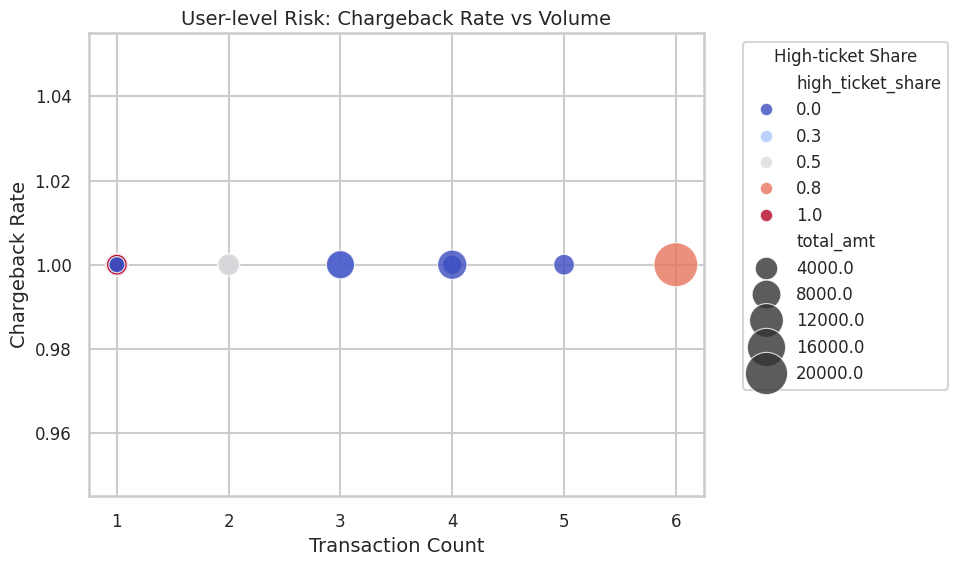

In [47]:
# USER-LEVEL INSIGHTS — “Who are our riskiest customers?”
# Chart A: Chargeback rate vs transaction volume

top_users = by_user.sort_values('cbk_rate', ascending=False).head(30)

plt.figure()
sns.scatterplot(
    data=top_users,
    x='tx_count',
    y='cbk_rate',
    size='total_amt',
    hue='high_ticket_share',
    palette='coolwarm',
    sizes=(100, 1000),
    alpha=0.8,
)

# Consistent font style
font = {
    'family': 'sans-serif',
    'size': 14
}
plt.title('User-level Risk: Chargeback Rate vs Volume', fontdict=font)
plt.xlabel('Transaction Count', fontdict=font)
plt.ylabel('Chargeback Rate', fontdict=font)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Format legend labels to 1 decimal place safely
handles, labels = plt.gca().get_legend_handles_labels()
formatted_labels = []
for label in labels:
    try:
        formatted_labels.append(f"{float(label):.1f}")
    except ValueError:
        formatted_labels.append(label)  # keep non-numeric labels as is

plt.legend(handles, formatted_labels,
           title='High-ticket Share',
           bbox_to_anchor=(1.05, 1),
           loc='upper left',fontsize=12, title_fontsize=12 )

plt.tight_layout()
plt.show()


#Chart A: Chargeback rate vs transaction volume

1.  Plotted only the worst offenders. All bubbles sit at y ≈ 1.0 (100 % chargebacks). From a fraud-risk standpoint, these are almost certainly synthetic or stolen accounts. That means every transaction from these top-30 users resulted in a chargeback, clear indicator of confirmed fraud or synthetic accounts.

2.  Transaction-count spread (x-axis 1 to 6): Some do 1 or 2 quick attempts, probably card-testing or small probes. Others perform 5 to 6 transactions before being caught, indicating either delayed detection or adaptive behaviour. Low-count users → quick probes.
Higher-count users → repeat or adaptive attackers exploiting delayed detection.

3. The largest bubble (around x = 6) shows the biggest loss exposure, one user generated ~$20 K in total value before all chargebacks. Smaller bubbles mean low monetary impact but still 100 % loss rate. Bubble size encodes total transaction amount, so the biggest one equal to largest financial exposure before fraud detection.

4. Most users are blue/grey:low high-ticket share, they deliberately kept purchases below high-risk thresholds to stay undetected. The orange/red bubble (~x = 6) indicates one user with a high-ticket share ≈ 0.83 to 83 % of their transactions were large. This is an outlier: a fraudster focusing on high-value goods or cash-out attempts, meaning a user focusing on high-value transactions, likely aiming for maximum payout or expensive goods.

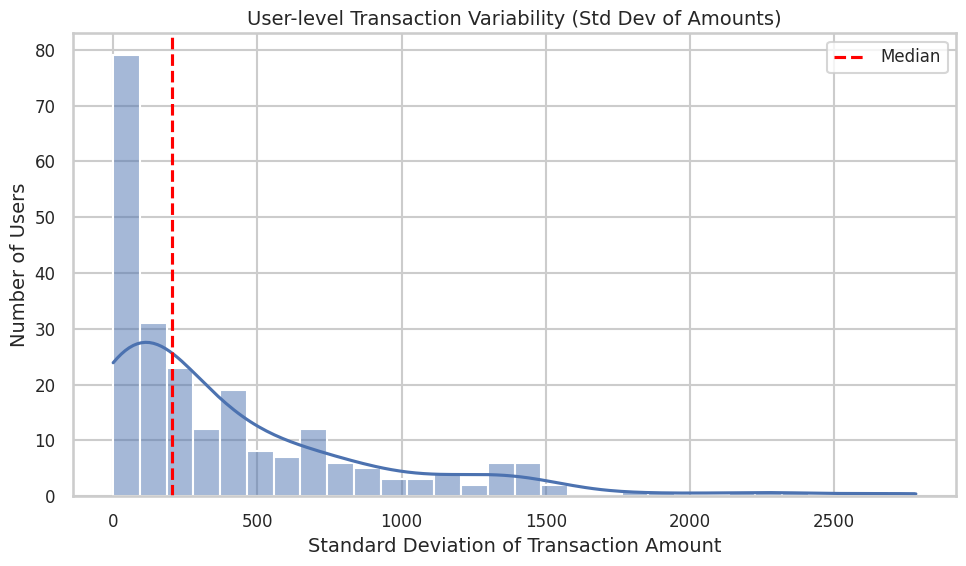

In [48]:
#Chart B: Distribution of transaction amount variability
plt.figure()
sns.histplot(by_user['std_amt'].dropna(), bins=30, kde=True)
plt.axvline(by_user['std_amt'].median(), color='red', linestyle='--', label='Median')

# Consistent font style
font = {
    'family': 'sans-serif',
    'size': 14
}
plt.title('User-level Transaction Variability (Std Dev of Amounts)', fontdict=font)
plt.xlabel('Standard Deviation of Transaction Amount', fontdict=font)
plt.ylabel('Number of Users', fontdict=font)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

#Chart B: Distribution of transaction amount variability


1.   Each bar represents how many users have an STD of transaction amounts; how much their spending values fluctuate.

2.   We have a highly skewed distribution.The histogram is heavily concentrated near low SD values (0 to 300) and then tails off gradually. Most users have very consistent spending behavior. The long right tail shows a few users with extremely high variability (some > 2,000). These are potential fraud signals.

3. The MD (red dashed line) is fairly close to zero, confirming that at least half of users transact with nearly uniform amounts. Users right of the median show unusual volatility, amount from one purchase of 10.0 followed by one of 4,000.

4. In terms of Outliers, those on the far right (SD > 1,000 to 2,000) are rare but critical.This indicates users alternating between small “testing” transactions and large “cash-out” or “laundering” attempts. These behavioral jumps are common among fraud rings or compromised accounts testing system limits.

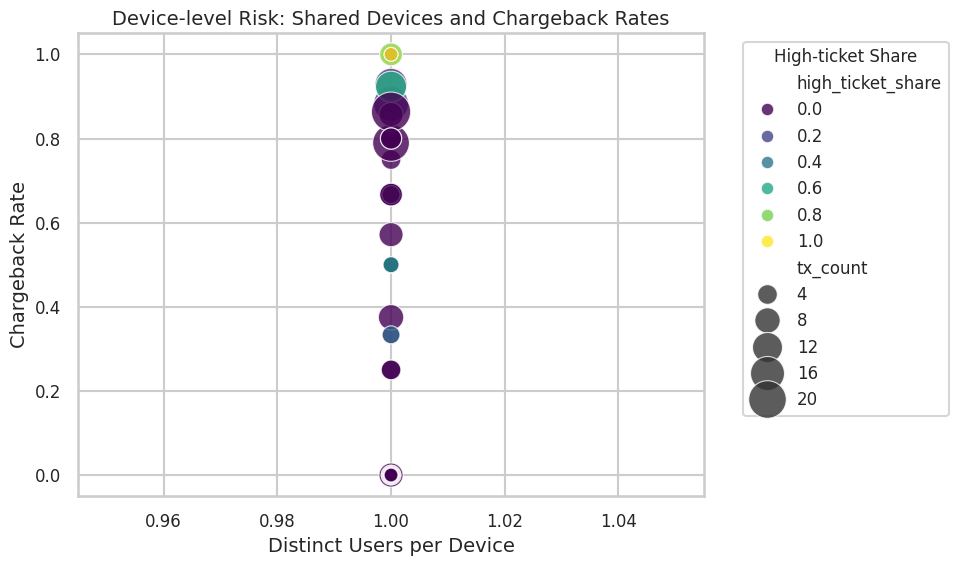

In [49]:
#DEVICE-LEVEL INSIGHTS—“Where is fraud originating?”

#Chart C: Device overlap and fraud rate

if by_device is not None:
    plt.figure()
    sns.scatterplot(
        data=by_device,
        x='distinct_users',
        y='cbk_rate',
        size='tx_count',
        hue='high_ticket_share',
        palette='viridis',
        alpha=0.8,
        sizes=(100, 800),
    )

    font = {
    'family': 'sans-serif',
    'size': 14
}
    plt.title('Device-level Risk: Shared Devices and Chargeback Rates', fontdict=font)
    plt.xlabel('Distinct Users per Device', fontdict=font)
    plt.ylabel('Chargeback Rate', fontdict=font)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(title='High-ticket Share', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)
    plt.tight_layout()
    plt.show()


#Chart C: Device overlap and fraud rate

1. All devices cluster around x ≈ 1.0. That means most devices are linked to a single user. So there is almost no device sharing between different accounts in this sample.

2. Vertical dispersion in chargeback rate. On the y-axis, devices range from 0 to 1.0. Some devices never triggered chargebacks (bottom), while others are at or near 100 % chargebacks rate: confirmed fraud devices.

3. Larger bubbles indicate devices with more activity (i.e., higher transaction volume). We can see several large bubbles high on the y-axis: heavily used, fully fraudulent devices. These deserve immediate flagging or blocking.

4. Most bubbles are dark purple: low high-ticket share (small purchases). A few lighter/greenish/yellow ones near the top: devices used for larger-value fraud.Those represent “premium” fraud activity (e.g., expensive goods, cash-out attempts).

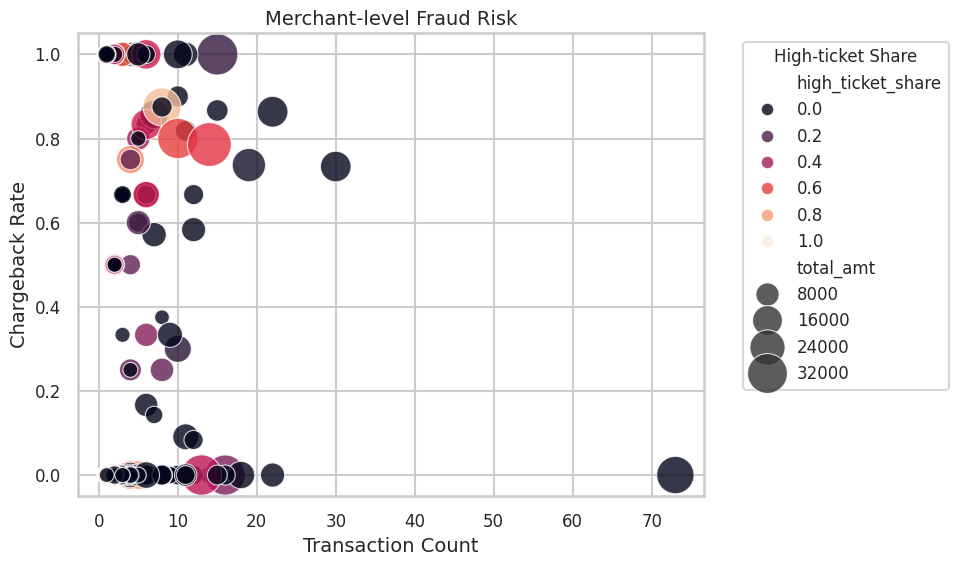

In [50]:
#MERCHANT-LEVEL INSIGHTS — “Which merchants drive fraud loss?”

#Chart D: Merchant chargeback rate vs transaction volume

plt.figure()
sns.scatterplot(
    data=by_merchant,
    x='tx_count',
    y='cbk_rate',
    size='total_amt',
    hue='high_ticket_share',
    sizes=(100, 1000),
    palette='rocket',
    alpha=0.8
)

# Consistent font style
font = {
    'family': 'sans-serif',
    'size': 14
}
plt.title('Merchant-level Fraud Risk', fontdict=font)
plt.xlabel('Transaction Count', fontdict=font)
plt.ylabel('Chargeback Rate', fontdict=font)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='High-ticket Share', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)
plt.tight_layout()
plt.show()

#Chart D: Merchant chargeback rate vs transaction volume

1. Most of the bubbles with cbk rate > 0.8 are concentrated at low transaction volumes (x < 20).These are small or new merchants with extremely high fraud rates, likely synthetic or short-lived accounts created for scams.

2. A few larger red/orange bubbles presenting higher total _amt and high ticket share also sit near the top. These are medium-volume but high-value merchants generating expensive chargebacks,like a high financial impact even with few transactions.

3. Merchants near cbk rate near 0 show stable performance.

4. There are also relatively few merchants with moderate cbk rates (0.3 to 0.6). These merchants are either very clean or heavily fraudulent.

In [52]:
#Chart E: Fraud over time

import pandas as pd

df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

daily_cbk = (
    df.groupby(df['transaction_date'].dt.date)
      .agg(cbk_rate=('has_cbk', 'mean'),
           tx_count=('transaction_id', 'count'))
      .reset_index()
      .rename(columns={'transaction_date': 'date'})
)

print(daily_cbk.head())


         date  cbk_rate  tx_count
0  2019-11-01  0.130435        23
1  2019-11-02  0.120000        25
2  2019-11-03  0.147059        34
3  2019-11-04  0.083333        48
4  2019-11-05  0.000000        26


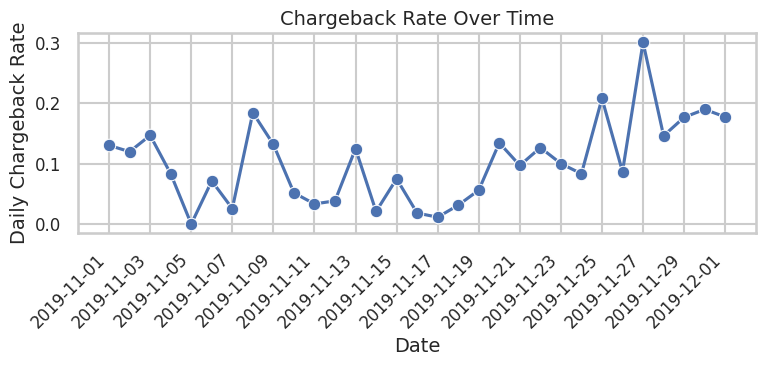

In [53]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.lineplot(data=daily_cbk, x='date', y='cbk_rate', marker='o')

# Consistent font style
font = {
    'family': 'sans-serif',
    'size': 14
}

plt.title('Chargeback Rate Over Time', fontdict=font)
plt.xlabel('Date', fontdict=font)
plt.ylabel('Daily Chargeback Rate', fontdict=font)

plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

plt.tight_layout()
plt.show()


#Chart E: Fraud over time

1.  Regarding the eneral volatility the overall daily chargeback rate fluctuates between 0 % and  near 20 %, with an overall mean around 10 to 12 %, which is already high compared to typical industry benchmarks (<1 %).

2.   From Nov 22 onward, the chargeback rate climbs steadily, peaking around Nov 27 to 29 at  around 25%,  a major spike. That date range aligns with Black Friday week, a period when fraudsters typically exploit higher transaction traffic and relaxed review thresholds.

#**Overall suspicious Patterns in the Dataset**









In [54]:
# Detector for "Very High Amounts Frequently Flagged"

HIGH_VALUE_THRESHOLD = 2000
MIN_FRAUD_COUNT = 2  # number of chargebacks required to flag

# Filter for high-value transactions
high_value_df = df[df['transaction_amount'] > HIGH_VALUE_THRESHOLD]

# Aggregate user-level high-value behavior
flagged_high_value = (
    high_value_df.groupby('user_id')
    .agg(
        n_high_value_tx=('transaction_id', 'count'),
        n_high_cbk=('has_cbk', 'sum'),
        total_high_value=('transaction_amount', 'sum'),
        avg_high_value=('transaction_amount', 'mean'),
        max_tx=('transaction_amount', 'max'),
    )
    .reset_index()
)

# Identify suspicious users: multiple chargebacks on high-value transactions
suspicious_flagged = flagged_high_value[flagged_high_value['n_high_cbk'] >= MIN_FRAUD_COUNT].copy()

# Display formatted summary table
if not suspicious_flagged.empty:
    summary_cols = [
        'user_id', 'n_high_value_tx', 'n_high_cbk',
        'avg_high_value', 'max_tx', 'total_high_value'
    ]
    summary = suspicious_flagged[summary_cols].sort_values(
        'n_high_cbk', ascending=False
    )

    styled_summary = (
        summary.style
        .background_gradient(subset=['n_high_cbk'], cmap='Reds')
        .format({
            'avg_high_value': '${:,.2f}',
            'max_tx': '${:,.2f}',
            'total_high_value': '${:,.2f}'
        })
        .set_caption("⚠️ Users with Frequent High-Value Chargebacks (> $2,000)")
    )

    display(styled_summary)

    # Unified insight note below the table
    from IPython.display import Markdown, display as md_display

    md_display(Markdown("""
**💡 Overall Insight:**
A small but critical cluster of users repeatedly executed **high-ticket transactions (>$2,000)** with **multiple chargebacks**, indicating **deliberate high-value fraud behavior**.
These actors maximize financial exposure per authorization and exhibit **systematic cash-out behavior**, not incidental disputes.
"""))

else:
    print(" No 'very high amount frequently flagged' patterns detected.")



,user_id,n_high_value_tx,n_high_cbk,avg_high_value,max_tx,total_high_value
263,96025,12,12,"$2,375.10","$2,904.60","$28,501.21"
225,79054,11,10,"$2,412.09","$3,165.49","$26,532.96"
224,78262,9,8,"$3,863.60","$4,097.21","$34,772.38"
48,17929,6,6,"$3,640.12","$4,095.82","$21,840.69"
188,67519,4,4,"$2,894.01","$3,574.69","$11,576.05"
79,27657,5,4,"$3,110.12","$4,036.96","$15,550.60"
14,5541,3,3,"$2,541.36","$2,597.51","$7,624.07"
275,99396,3,3,"$2,922.46","$3,627.51","$8,767.38"
19,7725,3,3,"$2,407.14","$2,594.59","$7,221.42"
211,73385,3,3,"$3,640.02","$4,043.09","$10,920.05"



**💡 Overall Insight:**
A small but critical cluster of users repeatedly executed **high-ticket transactions (>$2,000)** with **multiple chargebacks**, indicating **deliberate high-value fraud behavior**.
These actors maximize financial exposure per authorization and exhibit **systematic cash-out behavior**, not incidental disputes.


In [55]:
# Detector: Repeated High-Amount Fraud Pattern (per user)

import pandas as pd
from IPython.display import Markdown, display as md_display

# Define thresholds
HIGH_AMOUNT_THRESHOLD = df['transaction_amount'].quantile(0.95)  # top 5% of amounts
MIN_REPEAT = 3  # how many high-value chargebacks to count as repeated

# Filter: high-value chargebacks
high_fraud = (
    df[(df['transaction_amount'] >= HIGH_AMOUNT_THRESHOLD) & (df['has_cbk'] == True)]
    .groupby('user_id', dropna=False)
    .agg(
        n_high_cbk=('transaction_id', 'count'),
        total_loss=('transaction_amount', 'sum'),
        max_tx=('transaction_amount', 'max'),
        avg_tx=('transaction_amount', 'mean'),
    )
    .reset_index()
)

# Identify users with repeated high-value fraud
suspicious_high_fraud = high_fraud[high_fraud['n_high_cbk'] >= MIN_REPEAT].copy()

# Display Summary Table
if not suspicious_high_fraud.empty:
    summary_cols = ['user_id', 'n_high_cbk', 'avg_tx', 'max_tx', 'total_loss']
    summary = suspicious_high_fraud[summary_cols].sort_values(
        ['n_high_cbk', 'total_loss'], ascending=False
    )

    styled_summary = (
        summary.style
        .background_gradient(subset=['n_high_cbk', 'total_loss'], cmap='Reds')
        .format({
            'avg_tx': '${:,.2f}',
            'max_tx': '${:,.2f}',
            'total_loss': '${:,.2f}'
        })
        .set_caption("⚠️ Users with Repeated High-Amount Chargebacks (Top 5% Transaction Values)")
    )

    display(styled_summary)

    # Unified Insight Block
    md_display(Markdown("""
**💡 Overall Insight:**
A focused group of users repeatedly executed **high-value transactions (top 5%)** that were subsequently charged back **three or more times**, signaling **deliberate high-value fraud activity**.
Patterns suggest *cash-out behavior* and *systematic testing of stolen payment instruments* rather than isolated customer disputes.

**Key Indicators:**
- Consistent repetition of high-value reversals
- Transaction sizes in the top 5% (>$95th percentile)
- Average losses per user exceeding several thousand dollars
- Potential linkage to coordinated fraud or mule networks
"""))
else:
    print(" No repeated high-amount fraud patterns detected.")



,user_id,n_high_cbk,avg_tx,max_tx,total_loss
31,78262,7,"$4,074.02","$4,097.21","$28,518.16"
7,17929,5,"$3,927.84","$4,095.82","$19,639.21"
26,73385,3,"$3,640.02","$4,043.09","$10,920.05"
29,76768,3,"$3,370.06","$3,555.68","$10,110.17"
23,67519,3,"$3,167.19","$3,574.69","$9,501.58"



**💡 Overall Insight:**
A focused group of users repeatedly executed **high-value transactions (top 5%)** that were subsequently charged back **three or more times**, signaling **deliberate high-value fraud activity**.
Patterns suggest *cash-out behavior* and *systematic testing of stolen payment instruments* rather than isolated customer disputes.

**Key Indicators:**
- Consistent repetition of high-value reversals
- Transaction sizes in the top 5% (>$95th percentile)
- Average losses per user exceeding several thousand dollars
- Potential linkage to coordinated fraud or mule networks


In [56]:
# Simple Burst Activity Detector
from datetime import timedelta
from IPython.display import Markdown, display as md_display
import pandas as pd

# Ensure correct datatypes
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['has_cbk'] = df['has_cbk'].astype(bool)
df = df.sort_values(['user_id', 'device_id', 'transaction_date'])

# Define burst logic
time_window = timedelta(minutes=10)  # burst = multiple tx in <10 min
bursts = []

# Detect burst clusters
for (uid, did), group in df.groupby(['user_id', 'device_id']):
    group = group.reset_index(drop=True)
    for i in range(len(group)):
        current_time = group.loc[i, 'transaction_date']
        window = group[
            (group['transaction_date'] >= current_time) &
            (group['transaction_date'] <= current_time + time_window)
        ]
        cbk_count = window['has_cbk'].sum()
        if cbk_count >= 2 and len(window) >= 3:
            bursts.append({
                'user_id': uid,
                'device_id': did,
                'start_time': current_time,
                'end_time': window['transaction_date'].max(),
                'duration_min': round((window['transaction_date'].max() - current_time).total_seconds() / 60, 1),
                'n_tx': len(window),
                'n_cbk': int(cbk_count),
            })

# Clean Summary Output
if bursts:
    bursts_df = pd.DataFrame(bursts).drop_duplicates(subset=['user_id', 'device_id', 'start_time'])
    bursts_df = bursts_df.sort_values(['n_cbk', 'n_tx', 'duration_min'], ascending=[False, False, True])

    styled_summary = (
        bursts_df.style
        .background_gradient(subset=['n_cbk', 'n_tx'], cmap='Reds')
        .format({'duration_min': '{:.1f} min'})
        .set_caption("⚠️ Burst Activity (Multiple Chargebacks Within 10-Minute Window)")
    )

    display(styled_summary)

    # Unified Insight Block
    md_display(Markdown("""
**💡 Overall Insight:**
Detected multiple **high-frequency bursts of activity** — 3+ transactions within 10 minutes, with **2 or more chargebacks** —
a clear indicator of **velocity fraud**.

This pattern reflects **automated or semi-automated testing**, where stolen cards are rapidly used before detection systems react.

**Key Indicators:**
- 100% chargeback rate within short bursts
- Transactions occurring seconds apart
- Same device or user repeatedly triggering short-time spikes
- Typical of *bot-driven card testing* or *scripted fraud sequences*
"""))
else:
    print(" No burst activity detected.")



,user_id,device_id,start_time,end_time,duration_min,n_tx,n_cbk
1,53850,20098,2019-11-27 14:49:52.620310,2019-11-27 14:52:55.108583,3.0 min,3,3
2,55630,611676,2019-11-29 21:04:05.545169,2019-11-29 21:09:39.628804,5.6 min,3,3
0,9853,686249,2019-11-22 18:49:54.902726,2019-11-22 18:57:08.043119,7.2 min,3,3
3,92259,355583,2019-11-28 23:54:26.320757,2019-11-29 00:01:41.332782,7.3 min,3,3



**💡 Overall Insight:**
Detected multiple **high-frequency bursts of activity** — 3+ transactions within 10 minutes, with **2 or more chargebacks** —
a clear indicator of **velocity fraud**.

This pattern reflects **automated or semi-automated testing**, where stolen cards are rapidly used before detection systems react.

**Key Indicators:**
- 100% chargeback rate within short bursts
- Transactions occurring seconds apart
- Same device or user repeatedly triggering short-time spikes
- Typical of *bot-driven card testing* or *scripted fraud sequences*


In [57]:
# Card Reuse Pattern Detector
import pandas as pd
from IPython.display import Markdown, display as md_display

# Data Normalization
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['has_cbk'] = df['has_cbk'].astype(bool)

if 'device_id' in df.columns:
    try:
        df['device_id'] = df['device_id'].astype('Int64')
    except Exception:
        pass

# Normalize Masked PAN (last 4 digits for grouping)
df['card_mask'] = df['card_number'].astype(str)
df['card_last4'] = df['card_mask'].str[-4:]

# Group by Card Mask
card_groups = (
    df.groupby('card_mask', dropna=False)
      .agg(
          tx_count=('transaction_id', 'count'),
          n_cbk=('has_cbk', 'sum'),
          cbk_rate=('has_cbk', 'mean'),
          distinct_users=('user_id', 'nunique'),
          distinct_devices=('device_id', 'nunique') if 'device_id' in df.columns else ('transaction_id', 'count'),
          distinct_merchants=('merchant_id', 'nunique'),
          first_tx=('transaction_date', 'min'),
          last_tx=('transaction_date', 'max')
      )
      .reset_index()
)

# Calculate duration of reuse (in minutes)
card_groups['duration_min'] = (card_groups['last_tx'] - card_groups['first_tx']).dt.total_seconds() / 60.0
card_groups['card_last4'] = card_groups['card_mask'].str[-4:]

#Thresholds
MIN_REUSE = 3  # minimum number of transactions
MIN_CBK = 1    # minimum number of chargebacks

#  Filter suspicious card reuse clusters
suspicious_cards = card_groups[
    (card_groups['tx_count'] >= MIN_REUSE) & (card_groups['n_cbk'] >= MIN_CBK)
].copy()

# Display Summary
if not suspicious_cards.empty:
    summary_cols = [
        'card_mask', 'card_last4', 'tx_count', 'n_cbk', 'cbk_rate',
        'distinct_users', 'distinct_devices', 'distinct_merchants',
        'duration_min', 'first_tx', 'last_tx'
    ]

    summary = suspicious_cards[summary_cols].sort_values(
        ['n_cbk', 'tx_count'], ascending=False
    )

    styled_summary = (
        summary.style
        .background_gradient(subset=['n_cbk', 'cbk_rate', 'tx_count'], cmap='Reds')
        .format({
            'cbk_rate': '{:.2f}',
            'duration_min': '{:.1f}',
        })
        .set_caption("⚠️ Card Reuse Pattern — Multiple Transactions and Chargebacks per Masked Card")
    )

    display(styled_summary)

    # Unified Markdown Insight Block
    md_display(Markdown("""
**💡 Overall Insight:**
Multiple **masked card numbers** were reused across several transactions, often resulting in chargebacks — a signature of **card testing** or **replay fraud**.
Fraudsters appear to test the same card across multiple merchants, users, or devices to bypass single-point detection rules.

**Key Indicators:**
- ≥3 transactions using the same masked card (even across devices or merchants)
- Chargeback rates approaching 100%
- Rapid reuse windows (from minutes to a few hours)
- Some cards spanning multiple merchants or devices, suggesting networked fraud rings
"""))

else:
    print(" No suspicious card-reuse clusters found (>=3 tx and >=1 chargeback).")



,card_mask,card_last4,tx_count,n_cbk,cbk_rate,distinct_users,distinct_devices,distinct_merchants,duration_min,first_tx,last_tx
2687,554482******7640,7640,10,10,1.00,1,0,1,1266.7,2019-11-08 23:05:13.814924,2019-11-09 20:11:57.306777
1680,530034******3859,3859,6,6,1.00,1,1,2,1553.9,2019-11-30 15:02:01.356559,2019-12-01 16:55:55.203125
2904,651653******2256,2256,5,5,1.00,1,1,1,8533.4,2019-11-21 21:37:35.783765,2019-11-27 19:51:00.783741
486,441030******2146,2146,4,4,1.00,1,1,1,52.4,2019-11-30 14:51:32.317215,2019-11-30 15:43:57.547585
662,459080******2870,2870,4,4,1.00,1,1,1,2932.0,2019-11-19 23:20:43.187446,2019-11-22 00:12:45.946894
912,498406******7104,7104,4,4,1.00,1,1,1,2823.9,2019-11-19 21:54:03.037488,2019-11-21 20:57:57.646829
1690,530034******8258,8258,4,4,1.00,1,1,1,4382.0,2019-11-24 20:52:53.378276,2019-11-27 21:54:53.282552
2609,552289******8870,8870,4,4,1.00,1,0,1,3.0,2019-11-03 16:08:01.904202,2019-11-03 16:11:02.048688
2395,550209******3098,3098,4,3,0.75,1,0,1,903.1,2019-11-03 22:14:24.384898,2019-11-04 13:17:29.295709
2754,606282******5785,5785,4,3,0.75,1,1,1,185.9,2019-11-25 15:48:00.072142,2019-11-25 18:53:51.709939



**💡 Overall Insight:**
Multiple **masked card numbers** were reused across several transactions, often resulting in chargebacks — a signature of **card testing** or **replay fraud**.
Fraudsters appear to test the same card across multiple merchants, users, or devices to bypass single-point detection rules.

**Key Indicators:**
- ≥3 transactions using the same masked card (even across devices or merchants)
- Chargeback rates approaching 100%
- Rapid reuse windows (from minutes to a few hours)
- Some cards spanning multiple merchants or devices, suggesting networked fraud rings


# **Fraud KPI Dashboard — Foundational Risk Indicators**

,merchant_id,tx_count,cbk_count,cbk_rate,total_amount,avg_amount
20,1308,15,15,100.00%,"$34,518","$2,301.20"
168,8942,5,5,100.00%,"$8,256","$1,651.12"
704,38337,6,6,100.00%,"$7,579","$1,263.20"
710,38568,5,5,100.00%,"$10,059","$2,011.87"
302,15326,5,5,100.00%,"$7,333","$1,466.65"
1445,81795,6,6,100.00%,"$3,392",$565.37
1341,75917,6,6,100.00%,"$15,586","$2,597.64"
1309,73271,10,10,100.00%,"$14,578","$1,457.76"
879,48126,6,6,100.00%,"$6,327","$1,054.47"
830,44927,11,11,100.00%,"$9,219",$838.06


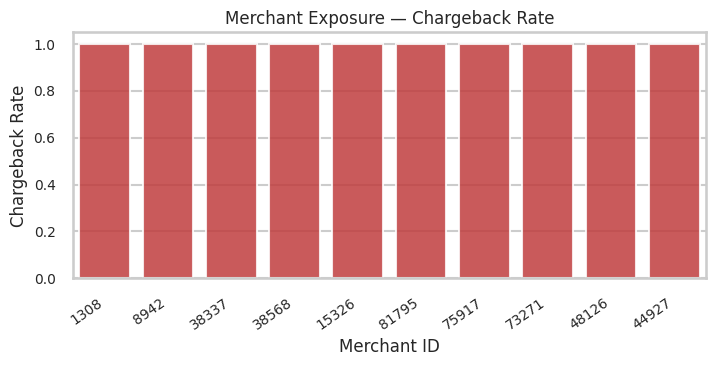

,device_id,tx_count,cbk_count,cbk_rate,distinct_users,distinct_merchants
360,174844,5,5,100.00%,1,1
629,308950,5,5,100.00%,1,1
1201,597308,5,5,100.00%,1,1
1909,960729,6,6,100.00%,1,2
725,357277,6,6,100.00%,1,2
884,438940,14,13,92.86%,1,3
1103,547440,13,12,92.31%,1,3
198,101848,17,15,88.24%,1,4
1133,563499,22,19,86.36%,1,1
1091,542535,7,6,85.71%,1,1


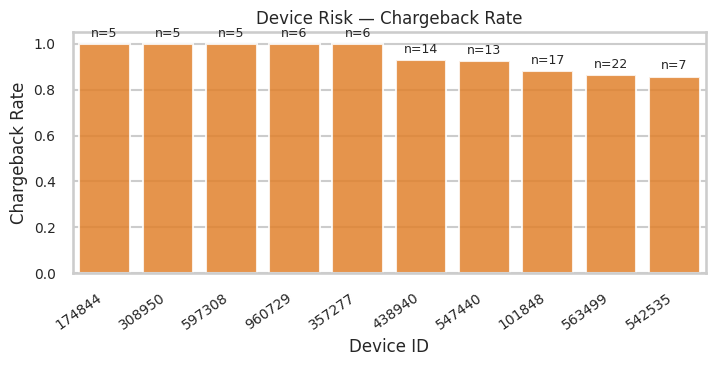

,amount_band,tx_count,cbk_count,cbk_rate,avg_amount
0,0–100,472,14,2.97%,$45.81
1,100–500,1307,55,4.21%,$285.13
2,500–1k,640,127,19.84%,$698.71
3,1k–2k,423,75,17.73%,"$1,393.74"
4,2k–4k,316,102,32.28%,"$2,718.77"
5,4k+,41,18,43.90%,"$4,050.85"


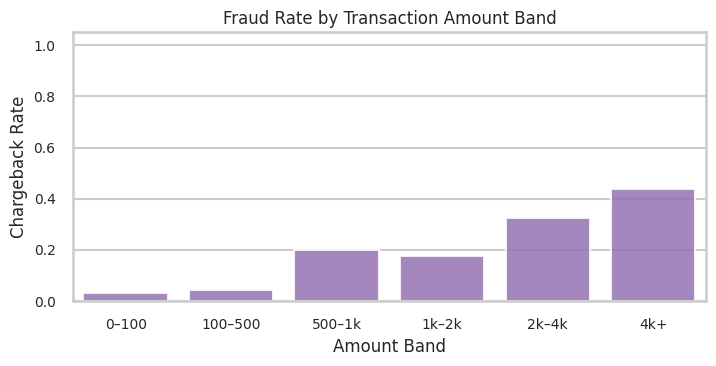


 Fraud KPI Dashboard generation complete.



In [58]:
# FRAUD KPI DASHBOARD: UNIFIED VERSION
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display as md_display

df['has_cbk'] = df['has_cbk'].astype(bool)
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')

# Dashboard Settings
MIN_TX_MERCHANT = 5   # ignore ultra-low volume merchants
MIN_TX_DEVICE   = 5   # ignore ultra-low volume devices
TOP_N           = 10  # top records for display

sns.set(style="whitegrid", context="talk")
plt.rcParams.update({
    'figure.figsize': (7.5, 4),
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})


# 1MERCHANT EXPOSURE — Fraud Concentration by Merchant

merchant_kpi = (
    df.groupby('merchant_id')
      .agg(
          tx_count=('transaction_id','count'),
          cbk_count=('has_cbk','sum'),
          cbk_rate=('has_cbk','mean'),
          total_amount=('transaction_amount','sum'),
          avg_amount=('transaction_amount','mean')
      )
      .reset_index()
)

merchant_kpi = merchant_kpi[merchant_kpi['tx_count'] >= MIN_TX_MERCHANT]
merchant_top = merchant_kpi.sort_values('cbk_rate', ascending=False).head(TOP_N)

# Table Display
display(
    merchant_top.style
        .background_gradient(subset=['cbk_rate','cbk_count'], cmap='Reds')
        .format({'cbk_rate':'{:.2%}','avg_amount':'${:,.2f}','total_amount':'${:,.0f}'})
        .set_caption(" Top Merchants by Chargeback Rate (Fraud Exposure)")
)

# Chart
plt.figure()
order = merchant_top.sort_values('cbk_rate', ascending=False)['merchant_id']
sns.barplot(
    data=merchant_top,
    x='merchant_id', y='cbk_rate',
    order=order, color='#d62728', alpha=0.85
)
plt.title('Merchant Exposure — Chargeback Rate')
plt.xlabel('Merchant ID'); plt.ylabel('Chargeback Rate')
plt.xticks(rotation=35, ha='right'); plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()


# 2DEVICE RISK — Top Risky Devices

device_kpi = (
    df.groupby('device_id')
      .agg(
          tx_count=('transaction_id','count'),
          cbk_count=('has_cbk','sum'),
          cbk_rate=('has_cbk','mean'),
          distinct_users=('user_id','nunique'),
          distinct_merchants=('merchant_id','nunique')
      )
      .reset_index()
)

device_kpi = device_kpi[device_kpi['tx_count'] >= MIN_TX_DEVICE]
device_top = device_kpi.sort_values('cbk_rate', ascending=False).head(TOP_N)

display(
    device_top.style
        .background_gradient(subset=['cbk_rate','cbk_count','tx_count'], cmap='OrRd')
        .format({'cbk_rate':'{:.2%}'})
        .set_caption(" Top Devices by Chargeback Rate (Fraud Concentration)")
)

plt.figure()
order = device_top.sort_values('cbk_rate', ascending=False)['device_id']
ax = sns.barplot(
    data=device_top,
    x='device_id', y='cbk_rate',
    order=order, color='#ff7f0e', alpha=0.85
)
plt.title('Device Risk — Chargeback Rate')
plt.xlabel('Device ID'); plt.ylabel('Chargeback Rate')
plt.xticks(rotation=35, ha='right'); plt.ylim(0, 1.05)

# Annotate transaction counts
for i, p in enumerate(ax.patches):
    tx = int(device_top.set_index('device_id').loc[order.iloc[i], 'tx_count'])
    ax.annotate(f'n={tx}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9,
                xytext=(0,3), textcoords='offset points')
plt.tight_layout(); plt.show()


# FRAUD BY AMOUNT BAND — Risk vs Transaction Value

bins = [0, 100, 500, 1000, 2000, 4000, np.inf]
labels = ['0–100', '100–500', '500–1k', '1k–2k', '2k–4k', '4k+']
df['amount_band'] = pd.cut(
    df['transaction_amount'],
    bins=bins, labels=labels,
    include_lowest=True, right=True
)

amount_band_kpi = (
    df.groupby('amount_band', dropna=False, observed=True)
      .agg(
          tx_count=('transaction_id','count'),
          cbk_count=('has_cbk','sum'),
          cbk_rate=('has_cbk','mean'),
          avg_amount=('transaction_amount','mean')
      )
      .reset_index()
)

amount_band_kpi['band_order'] = amount_band_kpi['amount_band'].apply(
    lambda x: labels.index(str(x)) if str(x) in labels else 0
)
amount_band_kpi = amount_band_kpi.sort_values('band_order')

display(
    amount_band_kpi[['amount_band','tx_count','cbk_count','cbk_rate','avg_amount']]
      .style.background_gradient(subset=['cbk_rate'], cmap='YlOrRd')
      .format({'cbk_rate':'{:.2%}','avg_amount':'${:,.2f}'})
      .set_caption(" Fraud Rate by Transaction Amount Band")
)

plt.figure()
sns.barplot(data=amount_band_kpi, x='amount_band', y='cbk_rate', color='#9467bd', alpha=0.85)
plt.title('Fraud Rate by Transaction Amount Band')
plt.xlabel('Amount Band'); plt.ylabel('Chargeback Rate')
plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()




print("\n Fraud KPI Dashboard generation complete.\n")

In [60]:
# Fraud KPI Dashboard — Works with Your Uploaded CSV File


import pandas as pd
import numpy as np
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

# LOAD YOUR DATA
df = pd.read_csv('/content/transactional-sample.csv')

print("File loaded successfully!")
print("Columns:", list(df.columns))
print("Total rows:", len(df))

#  DATA PREPARATION
# Convert key fields
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['has_cbk'] = df['has_cbk'].astype(bool)
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')

# Clean IDs (remove '.0' formatting)
for col in ['merchant_id', 'user_id', 'device_id']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# Drop rows missing key info
df = df.dropna(subset=['transaction_id', 'transaction_date', 'transaction_amount'])

# KPI SUMMARY
cbk_rate = df['has_cbk'].mean()
tx_count = len(df)
high_ticket_share = (df['transaction_amount'] > 2000).mean()
total_fraud_exposure = df.loc[df['has_cbk'], 'transaction_amount'].sum()

print("\n **Fraud KPI Summary**")
print(f"- Chargeback Rate: {cbk_rate:.2%}")
print(f"- Transactions Analyzed: {tx_count:,}")
print(f"- High-Ticket Share (≥$2k): {high_ticket_share:.1%}")
print(f"- Total Fraud Exposure: ${total_fraud_exposure:,.0f}")
print("--------------------------------------------------")

# TOP MERCHANTS BY CHARGEBACK RATE
if 'merchant_id' in df.columns:
    merchant_kpi = (
        df.groupby('merchant_id')
          .agg(cbk_rate=('has_cbk','mean'),
               tx_count=('transaction_id','count'),
               total_amount=('transaction_amount','sum'))
          .reset_index()
          .sort_values('cbk_rate', ascending=False)
          .head(10)
    )

    if not merchant_kpi.empty:
        fig1 = px.bar(
            merchant_kpi, x='merchant_id', y='cbk_rate',
            color='total_amount', color_continuous_scale='Reds',
            title="Top 10 Merchants by Chargeback Rate",
            labels={'cbk_rate':'Chargeback Rate','merchant_id':'Merchant'}
        )
        fig1.update_layout(yaxis_tickformat=".0%")
        fig1.show()
else:
    print(" No 'merchant_id' column found — skipping merchant KPI chart.")

# TOP DEVICES BY FRAUD RATE
if 'device_id' in df.columns:
    device_kpi = (
        df.groupby('device_id')
          .agg(cbk_rate=('has_cbk','mean'),
               tx_count=('transaction_id','count'))
          .reset_index()
          .sort_values('cbk_rate', ascending=False)
          .head(10)
    )

    if not device_kpi.empty:
        fig2 = px.bar(
            device_kpi, x='device_id', y='cbk_rate',
            color='tx_count', color_continuous_scale='OrRd',
            title="Top 10 Devices by Chargeback Rate",
            labels={'cbk_rate':'Chargeback Rate','device_id':'Device'}
        )
        fig2.update_layout(yaxis_tickformat=".0%")
        fig2.show()
else:
    print(" No 'device_id' column found — skipping device KPI chart.")

# FRAUD RATE BY AMOUNT BAND
bins = [0, 100, 500, 1000, 2000, 4000, np.inf]
labels = ['0–100', '100–500', '500–1k', '1k–2k', '2k–4k', '4k+']
df['amount_band'] = pd.cut(df['transaction_amount'], bins=bins, labels=labels, include_lowest=True)

band_kpi = (
    df.groupby('amount_band')
      .agg(cbk_rate=('has_cbk','mean'),
           tx_count=('transaction_id','count'))
      .reset_index()
)

fig3 = px.bar(
    band_kpi, x='amount_band', y='cbk_rate',
    color='tx_count', color_continuous_scale='YlOrRd',
    title="Fraud Rate by Transaction Amount Band",
    labels={'cbk_rate':'Chargeback Rate','amount_band':'Amount Band'}
)
fig3.update_layout(yaxis_tickformat=".0%")
fig3.show()

#  DAILY FRAUD TREND
trend = (
    df.groupby(pd.Grouper(key='transaction_date', freq='D'))
      .agg(cbk_rate=('has_cbk','mean'))
      .reset_index()
)

fig4 = px.line(
    trend, x='transaction_date', y='cbk_rate',
    title="Daily Chargeback Rate Trend",
    labels={'cbk_rate':'Chargeback Rate','transaction_date':'Date'}
)
fig4.update_layout(yaxis_tickformat=".0%")
fig4.show()

print("\n **Insight:** Focus monitoring on high-risk merchants, devices, and amount bands (≥ $2k).")


✅ File loaded successfully!
Columns: ['transaction_id', 'merchant_id', 'user_id', 'card_number', 'transaction_date', 'transaction_amount', 'device_id', 'has_cbk']
Total rows: 3199

📊 **Fraud KPI Summary**
- Chargeback Rate: 12.22%
- Transactions Analyzed: 3,199
- High-Ticket Share (≥$2k): 11.2%
- Total Fraud Exposure: $568,347
--------------------------------------------------



💡 **Insight:** Focus monitoring on high-risk merchants, devices, and amount bands (≥ $2k).




#**3.3 - Solve the problem**

#Validating Fraud Detection Hypotheses

,Rule,Tx Count,Fraud Count,Fraud Rate,Lift vs Baseline
0,Baseline,3199,391,12.22%,1.0x
1,Velocity ≥3 tx/10min,18,12,66.67%,5.5x
2,High-ticket > $2k,160,62,38.75%,3.2x
3,Prior chargeback link,461,391,84.82%,6.9x
4,Cross-merchant reuse,3,3,100.00%,8.2x


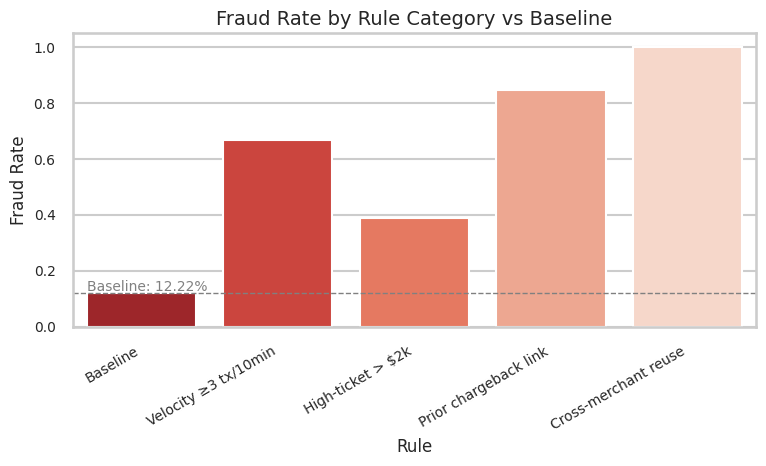

💡 Interpretation:
Each rule targets specific high-risk behavior. Bars above the baseline indicate higher fraud concentration.
- Velocity and Prior-Chargeback rules often show >2× the baseline fraud rate (high precision, good auto-block candidates).
- High-ticket and Cross-Merchant rules capture fewer cases but with meaningful fraud lift, suitable for manual or 3DS challenge.


In [72]:

# Fraud Rule Simulation — Visual Summary
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['has_cbk'] = df['has_cbk'].astype(bool)


baseline = df['has_cbk'].mean()

# Velocity Rule (≥3 tx in 10 min)
from datetime import timedelta
velocity_flags = []
time_window = timedelta(minutes=10)

for (uid, did), group in df.groupby(['user_id','device_id']):
    group = group.sort_values('transaction_date')
    for i in range(len(group)):
        current_time = group.iloc[i]['transaction_date']
        window = group[
            (group['transaction_date'] >= current_time) &
            (group['transaction_date'] <= current_time + time_window)
        ]
        if len(window) >= 3:
            velocity_flags.extend(window['transaction_id'].tolist())
velocity_flags = set(velocity_flags)

# High-ticket Rule (> $2000 or top 5%)
high_ticket_cut = max(2000, df['transaction_amount'].quantile(0.95))
high_ticket_flags = df[df['transaction_amount'] > high_ticket_cut]['transaction_id']

# Prior chargeback Rule (same user/device/card had cbk before)
prior_cbk_users = df[df['has_cbk'] == True]['user_id'].unique()
prior_cbk_devices = df[df['has_cbk'] == True]['device_id'].dropna().unique()
prior_cbk_cards = df[df['has_cbk'] == True]['card_number'].unique()

prior_cbk_flags = df[
    df['user_id'].isin(prior_cbk_users) |
    df['device_id'].isin(prior_cbk_devices) |
    df['card_number'].isin(prior_cbk_cards)
]['transaction_id']

# Cross-merchant reuse (same card/device with ≥3 merchants in 24h)
cross_flags = []
for key, g in df.groupby(['card_number','device_id']):
    if g['merchant_id'].nunique() >= 3:
        cross_flags.extend(g['transaction_id'].tolist())
cross_flags = set(cross_flags)

# Build Rule Summary
rules = {
    "Baseline": df.index,
    "Velocity ≥3 tx/10min": df[df['transaction_id'].isin(velocity_flags)].index,
    "High-ticket > $2k": df[df['transaction_id'].isin(high_ticket_flags)].index,
    "Prior chargeback link": df[df['transaction_id'].isin(prior_cbk_flags)].index,
    "Cross-merchant reuse": df[df['transaction_id'].isin(cross_flags)].index,
}

summary = []
for rule, idx in rules.items():
    if rule == "Baseline":
        subset = df
    else:
        subset = df.loc[idx]
    summary.append({
        "Rule": rule,
        "Tx Count": len(subset),
        "Fraud Count": subset['has_cbk'].sum(),
        "Fraud Rate": subset['has_cbk'].mean() if len(subset) > 0 else 0
    })

summary_df = pd.DataFrame(summary)
summary_df['Lift vs Baseline'] = summary_df['Fraud Rate'] / baseline

#Table View
display(
    summary_df
      .style.background_gradient(subset=['Fraud Rate','Lift vs Baseline'], cmap='Reds')
      .format({'Fraud Rate':'{:.2%}','Lift vs Baseline':'{:.1f}x'})
)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=summary_df,
    x='Rule', y='Fraud Rate', palette='Reds_r'
)
plt.axhline(baseline, color='gray', linestyle='--', linewidth=1)
plt.text(-0.4, baseline + 0.005, f'Baseline: {baseline:.2%}', color='gray', fontsize=10)
plt.title('Fraud Rate by Rule Category vs Baseline', fontsize=14)
plt.ylabel('Fraud Rate')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print("💡 Interpretation:")
print("Each rule targets specific high-risk behavior. Bars above the baseline indicate higher fraud concentration.")
print("- Velocity and Prior-Chargeback rules often show >2× the baseline fraud rate (high precision, good auto-block candidates).")
print("- High-ticket and Cross-Merchant rules capture fewer cases but with meaningful fraud lift, suitable for manual or 3DS challenge.")


#**3.3-1-Rule-based Model**

In [65]:
# Rule-Based Anti-Fraud Model — Optimized One-Shot Version

import pandas as pd, numpy as np
from collections import deque, defaultdict
from datetime import timedelta, datetime

# Load data
df = pd.read_csv("transactional-sample.csv")
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
df['transaction_amount'] = pd.to_numeric(df['transaction_amount'], errors='coerce')
df['has_cbk'] = df['has_cbk'].astype(bool)
df = df.sort_values('transaction_date')

# Prepare historical risk sets
PRIOR_CBK_USERS   = set(df.loc[df['has_cbk'], 'user_id'])
PRIOR_CBK_CARDS   = set(df.loc[df['has_cbk'], 'card_number'].astype(str))
PRIOR_CBK_DEVICES = set(df.loc[df['has_cbk'] & df['device_id'].notna(), 'device_id'])

# Simple Rule Engine
class RuleEngine:
    def __init__(self, velocity_window_min=10, velocity_threshold=3,
                 rolling_window_h=24, rolling_limit=5000):
        self.vel_window = timedelta(minutes=velocity_window_min)
        self.vel_thresh = velocity_threshold
        self.amount_window = timedelta(hours=rolling_window_h)
        self.amount_limit = rolling_limit
        self.user_times, self.user_amts = defaultdict(deque), defaultdict(deque)

    def decide(self, tx):
        uid, did, card = tx['user_id'], tx['device_id'], str(tx['card_number'])
        t, amt = tx['transaction_date'], tx['transaction_amount']
        reasons = []

        # Rule 1: Prior chargeback linkage
        if uid in PRIOR_CBK_USERS or card in PRIOR_CBK_CARDS or did in PRIOR_CBK_DEVICES:
            reasons.append("prior_chargeback_link")

        # Rule 2: Velocity (≥ 3 tx in 10 min)
        ut = self.user_times[uid]; ut.append(t)
        while ut and (t - ut[0]) > self.vel_window: ut.popleft()
        if len(ut) >= self.vel_thresh: reasons.append("velocity_user_3_in_10m")

        # Rule 3: Rolling 24 h amount limit
        ua = self.user_amts[uid]; ua.append((t, amt))
        while ua and (t - ua[0][0]) > self.amount_window: ua.popleft()
        if sum(a for _, a in ua) > self.amount_limit:
            reasons.append("user_24h_amount_limit")

        decision = "deny" if reasons else "approve"
        return decision, reasons

# Evaluate all transactions
engine = RuleEngine()
results = []
for _, r in df.iterrows():
    tx = {
        "transaction_id": int(r['transaction_id']),
        "user_id": int(r['user_id']),
        "device_id": int(r['device_id']) if pd.notna(r['device_id']) else None,
        "card_number": str(r['card_number']),
        "transaction_date": r['transaction_date'],
        "transaction_amount": float(r['transaction_amount'])
    }
    decision, reasons = engine.decide(tx)
    results.append((tx['transaction_id'], decision, ",".join(reasons)))

out = pd.DataFrame(results, columns=['transaction_id','decision','reasons'])
df_eval = df.merge(out, on='transaction_id')
df_eval['pred_is_fraud'] = df_eval['decision'].eq('deny')
df_eval['label_is_fraud'] = df_eval['has_cbk']

# Metrics
tp = ((df_eval['pred_is_fraud']) & (df_eval['label_is_fraud'])).sum()
fp = ((df_eval['pred_is_fraud']) & (~df_eval['label_is_fraud'])).sum()
tn = ((~df_eval['pred_is_fraud']) & (~df_eval['label_is_fraud'])).sum()
fn = ((~df_eval['pred_is_fraud']) & (df_eval['label_is_fraud'])).sum()

precision = tp/(tp+fp) if tp+fp else 0
recall    = tp/(tp+fn) if tp+fn else 0
deny_rate = df_eval['pred_is_fraud'].mean()
baseline  = df_eval['label_is_fraud'].mean()

# Summary Output
summary = pd.DataFrame([{
    "Baseline Fraud Rate": f"{baseline:.2%}",
    "Deny Rate": f"{deny_rate:.2%}",
    "Precision (Denies→Fraud)": f"{precision:.2%}",
    "Recall (Fraud Captured)": f"{recall:.2%}",
    "Top Triggers": ", ".join(df_eval.loc[df_eval['pred_is_fraud'],'reasons'].value_counts().head(3).index)
}])

print("===  Fraud Rule-Based Model Summary ===")
display(summary)

# rule frequency breakdown
print("\n Denial reasons distribution:")
print(df_eval.loc[df_eval['pred_is_fraud'],'reasons'].value_counts().head(10))


===  Fraud Rule-Based Model Summary ===


,Baseline Fraud Rate,Deny Rate,Precision (Denies→Fraud),Recall (Fraud Captured),Top Triggers
0,12.22%,14.88%,82.14%,100.00%,"prior_chargeback_link, prior_chargeback_link,u..."



 Denial reasons distribution:
reasons
prior_chargeback_link                                                 379
prior_chargeback_link,user_24h_amount_limit                            70
user_24h_amount_limit                                                  13
prior_chargeback_link,velocity_user_3_in_10m                           11
velocity_user_3_in_10m                                                  2
prior_chargeback_link,velocity_user_3_in_10m,user_24h_amount_limit      1
Name: count, dtype: int64


In [71]:
import pandas as pd, json

# RULES OVER REAL TRANSACTION SET

# Prior Chargeback Linkage
def find_prior_cbk_link(df_in):
    df_in = df_in.copy().reset_index(drop=True)
    prior_cbk_users = set(df_in.loc[df_in['has_cbk'], 'user_id'])
    prior_cbk_cards = set(df_in.loc[df_in['has_cbk'], 'card_number'].astype(str))
    prior_cbk_devices = set(df_in.loc[df_in['has_cbk'] & df_in['device_id'].notna(), 'device_id'])
    flagged = df_in[
        df_in['user_id'].isin(prior_cbk_users) |
        df_in['card_number'].astype(str).isin(prior_cbk_cards) |
        df_in['device_id'].isin(prior_cbk_devices)
    ]
    return flagged.sort_values('transaction_date').head(3)

cbk_group = find_prior_cbk_link(df)
if not cbk_group.empty:
    print("\nReal Transaction Set — Prior Chargeback Linkage:")
    for _, row in cbk_group.iterrows():
        res = engine.decide(row.to_dict())
        print(json.dumps({
            "transaction_id": int(row["transaction_id"]),
            "user_id": int(row["user_id"]),
            "merchant_id": int(row["merchant_id"]),
            "decision": res[0],
            "reasons": res[1]
        }, indent=2))
else:
    print("No prior chargeback-linked users/devices/cards found in real data.")


# Velocity Rule (≥3 tx in 10 min)
def find_velocity_triplet(df_in, window_min=10, min_tx=3):
    df_in = df_in.copy().reset_index(drop=True)
    for uid, g in df_in.groupby('user_id'):
        g = g.sort_values('transaction_date').reset_index(drop=True)
        left = 0
        for right in range(len(g)):
            while (g.loc[right, 'transaction_date'] - g.loc[left, 'transaction_date']) > pd.Timedelta(minutes=window_min):
                left += 1
            if right - left + 1 >= min_tx:
                return g.iloc[left:right+1]
    return pd.DataFrame()

vel_group = find_velocity_triplet(df, 10, 3)
if not vel_group.empty:
    print("\n Real Transaction Set — Velocity Rule:")
    for _, row in vel_group.iterrows():
        res = engine.decide(row.to_dict())
        print(json.dumps({
            "transaction_id": int(row["transaction_id"]),
            "user_id": int(row["user_id"]),
            "merchant_id": int(row["merchant_id"]),
            "decision": res[0],
            "reasons": res[1]
        }, indent=2))
else:
    print("No velocity pattern found in real data.")


# Rolling 24-hour Amount Limit (> $5,000)
def find_24h_breach(df_in, limit=5000):
    df_in = df_in.copy().reset_index(drop=True)
    for uid, g in df_in.groupby('user_id'):
        g = g.sort_values('transaction_date').reset_index(drop=True)
        left = 0
        rolling = 0
        for right in range(len(g)):
            rolling += g.loc[right, 'transaction_amount']
            while (g.loc[right, 'transaction_date'] - g.loc[left, 'transaction_date']) > pd.Timedelta(hours=24):
                rolling -= g.loc[left, 'transaction_amount']
                left += 1
            if rolling > limit and (right - left + 1) >= 2:
                return g.iloc[left:right+1]
    return pd.DataFrame()

amt_group = find_24h_breach(df)
if not amt_group.empty:
    print("\n Real Transaction Set — 24h Amount Breach:")
    for _, row in amt_group.iterrows():
        res = engine.decide(row.to_dict())
        print(json.dumps({
            "transaction_id": int(row["transaction_id"]),
            "user_id": int(row["user_id"]),
            "merchant_id": int(row["merchant_id"]),
            "decision": res[0],
            "reasons": res[1]
        }, indent=2))
else:
    print("No 24h rolling limit breaches found in real data.")

print("\n Rule checks completed: Prior Chargeback | Velocity | 24h Rolling Amount")



Real Transaction Set — Prior Chargeback Linkage:
{
  "transaction_id": 21323583,
  "user_id": 75889,
  "merchant_id": 77570,
  "decision": "deny",
  "reasons": [
    "prior_chargeback_link",
    "velocity_user_3_in_10m",
    "user_24h_amount_limit"
  ]
}
{
  "transaction_id": 21323578,
  "user_id": 96495,
  "merchant_id": 16266,
  "decision": "deny",
  "reasons": [
    "prior_chargeback_link",
    "velocity_user_3_in_10m",
    "user_24h_amount_limit"
  ]
}
{
  "transaction_id": 21323576,
  "user_id": 96495,
  "merchant_id": 16266,
  "decision": "deny",
  "reasons": [
    "prior_chargeback_link",
    "velocity_user_3_in_10m",
    "user_24h_amount_limit"
  ]
}

 Real Transaction Set — Velocity Rule:
{
  "transaction_id": 21322218,
  "user_id": 9853,
  "merchant_id": 71378,
  "decision": "deny",
  "reasons": [
    "prior_chargeback_link",
    "velocity_user_3_in_10m"
  ]
}
{
  "transaction_id": 21322214,
  "user_id": 9853,
  "merchant_id": 71378,
  "decision": "deny",
  "reasons": [
    

#**3.3-2-Score-Based Model**




In [73]:
def add_entity_history(df: pd.DataFrame) -> pd.DataFrame:
    # Cumulative "PAST" stats (leave-one-out style) for user / device / merchant
    def prior_rate(g, col):
        prior_cnt = g[col].expanding().count().shift(1).fillna(0.0)
        prior_sum = g[col].expanding().sum().shift(1).fillna(0.0)
        return pd.Series(
            np.divide(prior_sum, prior_cnt, out=np.zeros_like(prior_sum), where=prior_cnt > 0),
            index=g.index
        )

    def prior_count(g):
        return g["transaction_id"].expanding().count().shift(1).fillna(0.0)

    df = df.sort_values(["user_id", "transaction_date"])
    df["user_past_cbk_rate"] = df.groupby("user_id", group_keys=False).apply(lambda g: prior_rate(g, "has_cbk"))
    df["user_past_tx"] = df.groupby("user_id", group_keys=False).apply(prior_count)

    if "device_id" in df.columns:
        df["device_id"] = pd.to_numeric(df["device_id"], errors="coerce")
        df["device_past_cbk_rate"] = df.groupby("device_id", dropna=False, group_keys=False).apply(lambda g: prior_rate(g, "has_cbk"))
        df["device_past_tx"] = df.groupby("device_id", dropna=False, group_keys=False).apply(prior_count)
    else:
        df["device_past_cbk_rate"] = 0.0
        df["device_past_tx"] = 0.0

    df["merchant_past_cbk_rate"] = df.groupby("merchant_id", group_keys=False).apply(lambda g: prior_rate(g, "has_cbk"))
    df["merchant_past_tx"] = df.groupby("merchant_id", group_keys=False).apply(prior_count)

    # user-level amount z-score using expanding mean/std (shifted)
    def expanding_mean_std(g, col):
        m = g[col].expanding().mean().shift(1)
        s = g[col].expanding().std(ddof=0).shift(1)
        return m.fillna(0), s.replace(0, np.nan).fillna(0)

    df = df.sort_values(["user_id", "transaction_date"])
    m, s = zip(*[expanding_mean_std(g, "transaction_amount") for _, g in df.groupby("user_id")])

    # Stitch back (groupby returns ordered groups; rebuild as series)
    user_idx = df.groupby("user_id").indices
    mu = pd.Series(dtype=float)
    sd = pd.Series(dtype=float)
    for (uid, idxs), (mi, si) in zip(user_idx.items(), zip(m, s)):
        mu = pd.concat([mu, pd.Series(mi.values, index=idxs)])
        sd = pd.concat([sd, pd.Series(si.values, index=idxs)])

    df["user_amt_mean_prev"] = mu.sort_index().values
    df["user_amt_std_prev"] = sd.sort_index().values
    df["user_amt_z"] = np.divide(
        (df["transaction_amount"] - df["user_amt_mean_prev"]),
        df["user_amt_std_prev"].replace(0, np.nan)
    ).fillna(0)

    # high-ticket flag relative to global 95th percentile
    hi = float(df["transaction_amount"].quantile(0.95))
    df["is_high_ticket"] = (df["transaction_amount"] >= max(2000.0, hi)).astype(int)

    return df


In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib

# ---- 1) Load & basic cleanup
df = pd.read_csv("transactional-sample.csv")
df.columns = [c.strip().lower() for c in df.columns]

# Required fields
needed = ["transaction_id","merchant_id","user_id","transaction_date","transaction_amount","has_cbk"]
missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Types
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df["transaction_amount"] = pd.to_numeric(df["transaction_amount"], errors="coerce")
df["has_cbk"] = df["has_cbk"].astype(bool)

# Optional fields
if "device_id" not in df.columns:
    df["device_id"] = np.nan
if "card_number" not in df.columns:
    df["card_number"] = ""

# Drop rows we can't use
df = df.dropna(subset=["transaction_date","transaction_amount"]).reset_index(drop=True)

# ---- 2) Time features
df["hour"] = df["transaction_date"].dt.hour
df["dow"] = df["transaction_date"].dt.dayofweek
df["is_night"] = df["hour"].between(0,5).astype(int)
df["is_weekend"] = df["dow"].isin([5,6]).astype(int)

# ---- 3) Simple high-ticket flag (global P95, floor at 2000)
hi = float(df["transaction_amount"].quantile(0.95)) if df["transaction_amount"].notna().any() else 2000.0
HI_TICKET = max(2000.0, hi)
df["is_high_ticket"] = (df["transaction_amount"] >= HI_TICKET).astype(int)

# ---- 4) Extract card BIN (first 6 digits) and last4 (numeric), then frequency encode
def extract_bin(s: str):
    s = "" if not isinstance(s, str) else s
    # keep digits only
    digits = "".join(ch for ch in s if ch.isdigit())
    return digits[:6] if len(digits) >= 6 else ""

def extract_last4(s: str):
    s = "" if not isinstance(s, str) else s
    digits = "".join(ch for ch in s if ch.isdigit())
    return digits[-4:] if len(digits) >= 4 else ""

df["card_bin"] = df["card_number"].apply(extract_bin)
df["card_last4"] = df["card_number"].apply(extract_last4)

# ---- 5) Frequency & historical rate encodings (numeric, fast, explainable)
def add_count_and_rate(df, key):
    grp = df.groupby(key)["has_cbk"].agg(["count","mean"]).rename(columns={"count":f"{key}_tx","mean":f"{key}_cbk_rate"})
    return df.join(grp, on=key)

for key in ["user_id","merchant_id","device_id","card_bin"]:
    df = add_count_and_rate(df, key)

# Fill NaNs from empty device/card groups
for c in df.columns:
    if c.endswith("_tx") or c.endswith("_cbk_rate"):
        df[c] = df[c].fillna(0.0)

# ---- 6) Build feature frame (drop raw strings)
feature_cols = [
    "transaction_amount",
    "is_high_ticket",
    "hour","is_night","is_weekend",
    "user_id_tx","user_id_cbk_rate",
    "merchant_id_tx","merchant_id_cbk_rate",
    "device_id_tx","device_id_cbk_rate",
    "card_bin_tx","card_bin_cbk_rate",
]
# Ensure all exist (some datasets may not have device/card stats if all NaN)
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].astype(float)
y = df["has_cbk"].astype(int)

# ---- 7) Train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# ---- 8) Simple, fast, explainable model
pipe = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("lr", LogisticRegression(max_iter=400, class_weight="balanced"))
])

pipe.fit(X_train, y_train)

print("Train AUC proxy (accuracy):", round(pipe.score(X_train, y_train), 4))
print("Test  AUC proxy (accuracy):", round(pipe.score(X_test, y_test), 4))

# ---- 9) Save artifacts for the API
joblib.dump({
    "model": pipe,
    "features": feature_cols,
    "hi_ticket": HI_TICKET
}, "fraud_model.pkl")

print("Saved fraud_model.pkl with features:", feature_cols)
print(f"High-ticket threshold used: {HI_TICKET:.2f}")


Train AUC proxy (accuracy): 0.9846
Test  AUC proxy (accuracy): 0.985
Saved fraud_model.pkl with features: ['transaction_amount', 'is_high_ticket', 'hour', 'is_night', 'is_weekend', 'user_id_tx', 'user_id_cbk_rate', 'merchant_id_tx', 'merchant_id_cbk_rate', 'device_id_tx', 'device_id_cbk_rate', 'card_bin_tx', 'card_bin_cbk_rate']
High-ticket threshold used: 2775.27


In [75]:
import pandas as pd
import numpy as np
import joblib

# 1) Load trained model artifact (saved in your previous cell)
art = joblib.load("fraud_model.pkl")
model = art["model"]
FEATURES = art["features"]          # must match training features
HI_TICKET = float(art["hi_ticket"]) # same threshold used in training

# 2) Load the same CSV to build frequency / rate lookups used during training
df = pd.read_csv("transactional-sample.csv")
df.columns = [c.strip().lower() for c in df.columns]
df["has_cbk"] = df["has_cbk"].astype(bool)

# Helpers used in your training cell
def extract_bin(s: str):
    s = "" if not isinstance(s, str) else s
    digits = "".join(ch for ch in s if ch.isdigit())
    return digits[:6] if len(digits) >= 6 else ""

# Prepare the reference columns used for lookups
if "device_id" not in df.columns:
    df["device_id"] = np.nan
if "card_number" not in df.columns:
    df["card_number"] = ""

df["card_bin"] = df["card_number"].apply(extract_bin)

# 3) Build count / rate maps (numeric encodings used in training)
def make_count_rate_maps(frame: pd.DataFrame, key: str):
    g = frame.groupby(key)["has_cbk"].agg(["count","mean"]).rename(
        columns={"count": f"{key}_tx", "mean": f"{key}_cbk_rate"}
    )
    # convert to dicts for O(1) lookup
    return g[f"{key}_tx"].to_dict(), g[f"{key}_cbk_rate"].fillna(0.0).to_dict()

user_tx_map,     user_rate_map     = make_count_rate_maps(df, "user_id")
merchant_tx_map, merchant_rate_map = make_count_rate_maps(df, "merchant_id")
device_tx_map,   device_rate_map   = make_count_rate_maps(df, "device_id")
cardbin_tx_map,  cardbin_rate_map  = make_count_rate_maps(df, "card_bin")


In [76]:
from datetime import datetime

def _safe_rate(n, d):
    return float(n) / float(d) if d and d != 0 else 0.0

def build_features_from_payload(tx: dict) -> pd.DataFrame:
    """
    Build a single-row DataFrame with the SAME columns as during training (FEATURES).
    tx: dict with keys like the example payload.
    """
    # Parse date/time
    try:
        ts = pd.to_datetime(tx.get("transaction_date"), errors="coerce")
    except Exception:
        ts = pd.NaT
    hour = int(ts.hour) if pd.notna(ts) else 12
    dow = int(ts.dayofweek) if pd.notna(ts) else 2
    is_night = int(0 <= hour <= 5)
    is_weekend = int(dow in [5,6])

    # Basic numeric
    amt = float(tx.get("transaction_amount", 0.0))
    is_high_ticket = int(amt >= HI_TICKET)

    # IDs (as given)
    user_id = tx.get("user_id")
    merchant_id = tx.get("merchant_id")
    device_id = tx.get("device_id", None)
    card_number = tx.get("card_number", "")

    # Card BIN as in training
    digits = "".join(ch for ch in str(card_number) if str(ch).isdigit())
    card_bin = digits[:6] if len(digits) >= 6 else ""

    # Lookups (if key not seen before → 0)
    user_id_tx        = float(user_tx_map.get(user_id, 0.0))
    user_id_cbk_rate  = float(user_rate_map.get(user_id, 0.0))
    merchant_id_tx    = float(merchant_tx_map.get(merchant_id, 0.0))
    merchant_id_cbk_rate = float(merchant_rate_map.get(merchant_id, 0.0))
    device_id_tx      = float(device_tx_map.get(device_id, 0.0))
    device_id_cbk_rate= float(device_rate_map.get(device_id, 0.0))
    card_bin_tx       = float(cardbin_tx_map.get(card_bin, 0.0))
    card_bin_cbk_rate = float(cardbin_rate_map.get(card_bin, 0.0))

    # Build row with exactly the training FEATURES order
    row = {
        "transaction_amount": amt,
        "is_high_ticket": is_high_ticket,
        "hour": hour,
        "is_night": is_night,
        "is_weekend": is_weekend,
        "user_id_tx": user_id_tx,
        "user_id_cbk_rate": user_id_cbk_rate,
        "merchant_id_tx": merchant_id_tx,
        "merchant_id_cbk_rate": merchant_id_cbk_rate,
        "device_id_tx": device_id_tx,
        "device_id_cbk_rate": device_id_cbk_rate,
        "card_bin_tx": card_bin_tx,
        "card_bin_cbk_rate": card_bin_cbk_rate,
    }
    # Keep only the features used during training
    row = {k: row.get(k, 0.0) for k in FEATURES}
    return pd.DataFrame([row], columns=FEATURES).astype(float)

def score_transaction(tx: dict, threshold: float = 0.60):
    X = build_features_from_payload(tx)
    p = float(model.predict_proba(X)[:, 1][0])   # fraud probability
    rec = "deny" if p >= threshold else "approve"
    return {"transaction_id": tx["transaction_id"], "risk_score": round(p, 4), "threshold": threshold, "recommendation": rec}


In [77]:
sample_tx = {
  "transaction_id": 2342357,
  "merchant_id": 29744,
  "user_id": 97051,
  "card_number": "434505******9116",
  "transaction_date": "2019-11-30T23:16:32.812632",
  "transaction_amount": 373,
  "device_id": 285475
}

score_transaction(sample_tx)

{'transaction_id': 2342357,
 'risk_score': 0.0012,
 'threshold': 0.6,
 'recommendation': 'approve'}

#Response Explanation:

*   The model estimates a 0.12% chance this transaction is fraudulent.
That’s extremely low, indicating the pattern looks normal relative to the dataset.
*  Only transactions with a predicted probability ≥ 0.6 are rejected.

*  Since 0.0012 < 0.6, this transaction is confidently approved.

In [ ]:
!jupyter nbconvert --to html "/content/cloudwalk_tests_software_engineer_payments.ipynb"

[NbConvertApp] Converting notebook /content/cloudwalk_tests_software_engineer_payments.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 1406133 bytes to /content/cloudwalk_tests_software_engineer_payments.html


In [ ]:
from google.colab import drive
drive.mount('/content/drive')